<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/13_Local_SHAP_Explainability_Top_K_Recommendations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 13 — Local SHAP Explainability for Top-K Recommendations

## Explaining Why Products Are Recommended

This notebook provides local SHAP explanations for individual
next-basket recommendations generated by the temporal XGBoost ranking model.

While Notebook 9 analyzed global feature importance across the model,
this notebook focuses on individual recommendation decisions.

### Objectives

- Load the trained temporal XGBoost ranking model.
- Load the generated Top-K recommendations.
- Calculate SHAP values for individual candidate products.
- Identify the features contributing positively or negatively to each recommendation.
- Analyze explanations for Top-K recommended products.
- Aggregate local explanations across recommendations.
- Generate interpretable SHAP visualizations.
- Save recommendation-level explanation results.

### Explainability Perspective

For each recommended product, SHAP values indicate how individual
features contribute to the model's prediction relative to the model's
baseline output.

This helps explain recommendations using historical purchase frequency,
recency, purchase span, basket behavior, and other temporal features.

The analysis focuses on explanation rather than causal interpretation.

In [1]:
# ============================================================
# CELL 2 — IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os
import gc
import shap
import matplotlib.pyplot as plt

from xgboost import XGBRanker

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0


In [2]:
# ============================================================
# CELL 3 — CONFIGURE PROJECT PATHS
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/ML_Market_Basket_Analysis"

DATA_PATH = os.path.join(BASE_PATH, "Datasets")
MODEL_PATH = os.path.join(BASE_PATH, "Models", "Model_Outputs")

TOP_K_PATH = os.path.join(
    DATA_PATH,
    "Model_Outputs",
    "top20_recommendations_1000_validation_orders.csv"
)

MODEL_FILE = os.path.join(
    MODEL_PATH,
    "xgboost_next_basket_ranker.json"
)

OUTPUT_PATH = MODEL_PATH

print("Project paths configured successfully.")
print("Top-K recommendations:", TOP_K_PATH)
print("XGBoost model:", MODEL_FILE)
print("Output path:", OUTPUT_PATH)

Mounted at /content/drive
Project paths configured successfully.
Top-K recommendations: /content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets/Model_Outputs/top20_recommendations_1000_validation_orders.csv
XGBoost model: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/xgboost_next_basket_ranker.json
Output path: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs


In [3]:
# ============================================================
# CELL 4 — LOAD TRAINED XGBOOST MODEL
# ============================================================

model = XGBRanker()

model.load_model(MODEL_FILE)

print("XGBoost model loaded successfully.")
print("Model type:", type(model).__name__)
print("Number of estimators:", model.n_estimators)

XGBoost model loaded successfully.
Model type: XGBRanker
Number of estimators: None


In [4]:
# ============================================================
# CELL 5 — LOAD TOP-K RECOMMENDATIONS
# ============================================================

recommendations = pd.read_csv(TOP_K_PATH)

print("Top-K recommendation data loaded successfully.")
print("Shape:", recommendations.shape)
print("Columns:")
print(recommendations.columns.tolist())
print("Unique target orders:", recommendations["order_id"].nunique())

Top-K recommendation data loaded successfully.
Shape: (20000, 23)
Columns:
['order_id', 'user_id', 'order_number', 'product_id', 'in_next_basket', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'times_purchased_before', 'first_purchase_before', 'last_purchase_before', 'recency_before', 'purchase_span_before', 'was_previously_purchased', 'aisle_id', 'department_id', 'previous_orders', 'avg_basket_before', 'max_basket_before', 'total_items_before', 'order_progress', 'recommendation_score', 'rank']
Unique target orders: 1000


In [5]:
# ============================================================
# CELL 6 — DEFINE MODEL FEATURES
# ============================================================

feature_cols = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased",
    "aisle_id",
    "department_id",
    "previous_orders",
    "avg_basket_before",
    "max_basket_before",
    "total_items_before",
    "order_progress"
]

X_recommendations = recommendations[feature_cols].copy()

print("Model features prepared successfully.")
print("Number of features:", len(feature_cols))
print("Feature matrix shape:", X_recommendations.shape)
print("Missing values:", X_recommendations.isnull().sum().sum())

Model features prepared successfully.
Number of features: 17
Feature matrix shape: (20000, 17)
Missing values: 0


In [6]:
# ============================================================
# CELL 7 — CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully.")
print("Explainer type:", type(explainer).__name__)

SHAP TreeExplainer created successfully.
Explainer type: TreeExplainer


In [7]:
# ============================================================
# CELL 8 — CALCULATE LOCAL SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(X_recommendations)

print("SHAP values calculated successfully.")
print("SHAP matrix shape:", shap_values.shape)
print("Number of explained recommendations:", shap_values.shape[0])
print("Number of explained features:", shap_values.shape[1])


SHAP values calculated successfully.
SHAP matrix shape: (20000, 17)
Number of explained recommendations: 20000
Number of explained features: 17


In [8]:
# ============================================================
# CELL 9 — CREATE SHAP DATAFRAME
# ============================================================

shap_df = pd.DataFrame(
    shap_values,
    columns=[f"SHAP_{col}" for col in feature_cols]
)

shap_df = pd.concat(
    [
        recommendations[
            [
                "order_id",
                "user_id",
                "product_id",
                "rank",
                "recommendation_score",
                "in_next_basket"
            ]
        ].reset_index(drop=True),
        shap_df.reset_index(drop=True)
    ],
    axis=1
)

print("SHAP explanation dataframe created successfully.")
print("Shape:", shap_df.shape)
print("Columns:", shap_df.columns.tolist())

SHAP explanation dataframe created successfully.
Shape: (20000, 23)
Columns: ['order_id', 'user_id', 'product_id', 'rank', 'recommendation_score', 'in_next_basket', 'SHAP_order_number', 'SHAP_order_dow', 'SHAP_order_hour_of_day', 'SHAP_days_since_prior_order', 'SHAP_times_purchased_before', 'SHAP_first_purchase_before', 'SHAP_last_purchase_before', 'SHAP_recency_before', 'SHAP_purchase_span_before', 'SHAP_was_previously_purchased', 'SHAP_aisle_id', 'SHAP_department_id', 'SHAP_previous_orders', 'SHAP_avg_basket_before', 'SHAP_max_basket_before', 'SHAP_total_items_before', 'SHAP_order_progress']


In [9]:
# ============================================================
# CELL 10 — IDENTIFY TOP SHAP CONTRIBUTORS
# ============================================================

shap_feature_names = [f"SHAP_{col}" for col in feature_cols]

def get_top_shap_features(row, n=3):
    values = row[shap_feature_names].astype(float)

    top_features = values.abs().sort_values(ascending=False).head(n).index

    return ", ".join(
        feature.replace("SHAP_", "")
        for feature in top_features
    )

shap_df["top_shap_features"] = shap_df.apply(
    get_top_shap_features,
    axis=1
)

print("Top SHAP contributors identified successfully.")
print(shap_df[
    [
        "order_id",
        "product_id",
        "rank",
        "recommendation_score",
        "top_shap_features"
    ]
].head(10))

Top SHAP contributors identified successfully.
   order_id  product_id  rank  recommendation_score  \
0      3916       43545     1              3.464279   
1      3916       13176     2              3.423945   
2      3916        4793     3              2.776508   
3      3916       25931     4              2.589228   
4      3916        9839     5              2.061284   
5      3916       28597     6              2.000605   
6      3916       17795     7              1.713794   
7      3916       44359     8              1.445639   
8      3916       24390     9              1.218999   
9      3916        1749    10              0.837077   

                                   top_shap_features  
0  times_purchased_before, total_items_before, fi...  
1  times_purchased_before, first_purchase_before,...  
2  times_purchased_before, total_items_before, fi...  
3  times_purchased_before, total_items_before, fi...  
4  times_purchased_before, total_items_before, fi...  
5  times_purchase

In [10]:
# ============================================================
# CELL 11 — IDENTIFY POSITIVE AND NEGATIVE SHAP CONTRIBUTORS
# ============================================================

def get_shap_direction(row, n=3):
    values = row[shap_feature_names].astype(float)

    top_features = values.abs().sort_values(ascending=False).head(n)

    positive = []
    negative = []

    for feature in top_features.index:
        original_feature = feature.replace("SHAP_", "")

        if values[feature] > 0:
            positive.append(original_feature)
        elif values[feature] < 0:
            negative.append(original_feature)

    return (
        ", ".join(positive) if positive else "None",
        ", ".join(negative) if negative else "None"
    )

directions = shap_df.apply(get_shap_direction, axis=1)

shap_df["positive_shap_features"] = directions.apply(lambda x: x[0])
shap_df["negative_shap_features"] = directions.apply(lambda x: x[1])

print("SHAP contribution directions identified successfully.")

print(
    shap_df[
        [
            "order_id",
            "product_id",
            "rank",
            "recommendation_score",
            "positive_shap_features",
            "negative_shap_features"
        ]
    ].head(10)
)

SHAP contribution directions identified successfully.
   order_id  product_id  rank  recommendation_score  \
0      3916       43545     1              3.464279   
1      3916       13176     2              3.423945   
2      3916        4793     3              2.776508   
3      3916       25931     4              2.589228   
4      3916        9839     5              2.061284   
5      3916       28597     6              2.000605   
6      3916       17795     7              1.713794   
7      3916       44359     8              1.445639   
8      3916       24390     9              1.218999   
9      3916        1749    10              0.837077   

                          positive_shap_features  \
0  times_purchased_before, first_purchase_before   
1  times_purchased_before, first_purchase_before   
2  times_purchased_before, first_purchase_before   
3  times_purchased_before, first_purchase_before   
4  times_purchased_before, first_purchase_before   
5  times_purchased_before, f

In [11]:
# ============================================================
# CELL 12 — AGGREGATE LOCAL SHAP IMPORTANCE
# ============================================================

mean_abs_shap = {}

for feature in feature_cols:
    shap_column = f"SHAP_{feature}"
    mean_abs_shap[feature] = shap_df[shap_column].abs().mean()

local_shap_summary = (
    pd.DataFrame(
        list(mean_abs_shap.items()),
        columns=["feature", "mean_abs_shap"]
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("Local SHAP importance calculated successfully.")
print()
print(local_shap_summary)

Local SHAP importance calculated successfully.

                     feature  mean_abs_shap
0     times_purchased_before       1.993756
1         total_items_before       0.677351
2             recency_before       0.557335
3      first_purchase_before       0.492725
4               order_number       0.223136
5       purchase_span_before       0.124274
6          avg_basket_before       0.117592
7          max_basket_before       0.091009
8                   aisle_id       0.080944
9              department_id       0.063463
10      last_purchase_before       0.050031
11           previous_orders       0.040365
12    days_since_prior_order       0.037291
13         order_hour_of_day       0.011992
14                 order_dow       0.007859
15            order_progress       0.007561
16  was_previously_purchased       0.000000


In [12]:
# ============================================================
# CELL 13 — SAVE LOCAL SHAP SUMMARY
# ============================================================

local_shap_summary_path = os.path.join(
    OUTPUT_PATH,
    "local_shap_feature_importance.csv"
)

local_shap_summary.to_csv(
    local_shap_summary_path,
    index=False
)

print("Local SHAP summary saved successfully.")
print("Saved to:", local_shap_summary_path)
print("Rows:", len(local_shap_summary))

Local SHAP summary saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/local_shap_feature_importance.csv
Rows: 17


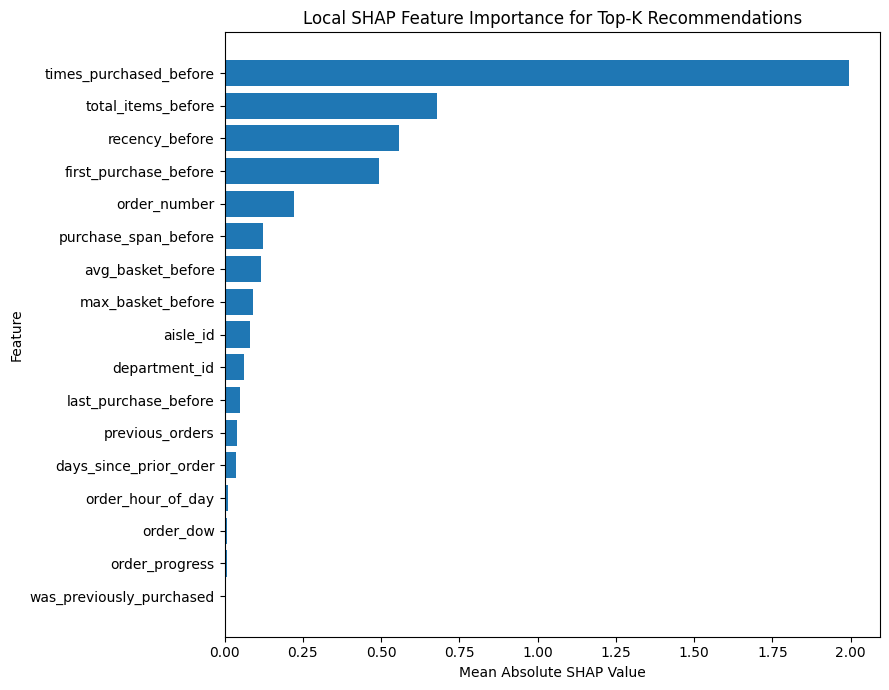

Local SHAP feature importance plot saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/local_shap_feature_importance.png


In [13]:
# ============================================================
# CELL 14 — LOCAL SHAP FEATURE IMPORTANCE PLOT
# ============================================================

plot_data = local_shap_summary.sort_values(
    "mean_abs_shap",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_data["feature"],
    plot_data["mean_abs_shap"]
)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")
ax.set_title("Local SHAP Feature Importance for Top-K Recommendations")

plt.tight_layout()

local_shap_plot_path = os.path.join(
    OUTPUT_PATH,
    "local_shap_feature_importance.png"
)

plt.savefig(
    local_shap_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Local SHAP feature importance plot saved successfully.")
print("Saved to:", local_shap_plot_path)

In [14]:
# ============================================================
# CELL 15 — EXPLAIN ONE TOP-RANKED RECOMMENDATION
# ============================================================

example_row = shap_df[
    (shap_df["rank"] == 1)
].iloc[0]

example_shap = pd.DataFrame({
    "feature": feature_cols,
    "shap_value": [
        example_row[f"SHAP_{feature}"]
        for feature in feature_cols
    ]
})

example_shap["absolute_shap"] = example_shap["shap_value"].abs()

example_shap = example_shap.sort_values(
    "absolute_shap",
    ascending=False
).head(10)

print("Example local recommendation explanation")
print("-----------------------------------------")
print("Order ID:", example_row["order_id"])
print("Product ID:", example_row["product_id"])
print("Recommendation rank:", example_row["rank"])
print("Recommendation score:", example_row["recommendation_score"])
print()
print("Top SHAP contributors:")
print(example_shap[["feature", "shap_value"]].to_string(index=False))

Example local recommendation explanation
-----------------------------------------
Order ID: 3916
Product ID: 43545
Recommendation rank: 1
Recommendation score: 3.4642792

Top SHAP contributors:
               feature  shap_value
times_purchased_before    3.856366
    total_items_before   -0.529946
 first_purchase_before    0.479912
        recency_before    0.406649
  purchase_span_before   -0.212769
          order_number   -0.150735
     max_basket_before   -0.121534
     avg_basket_before   -0.111034
days_since_prior_order   -0.081160
         department_id   -0.072945


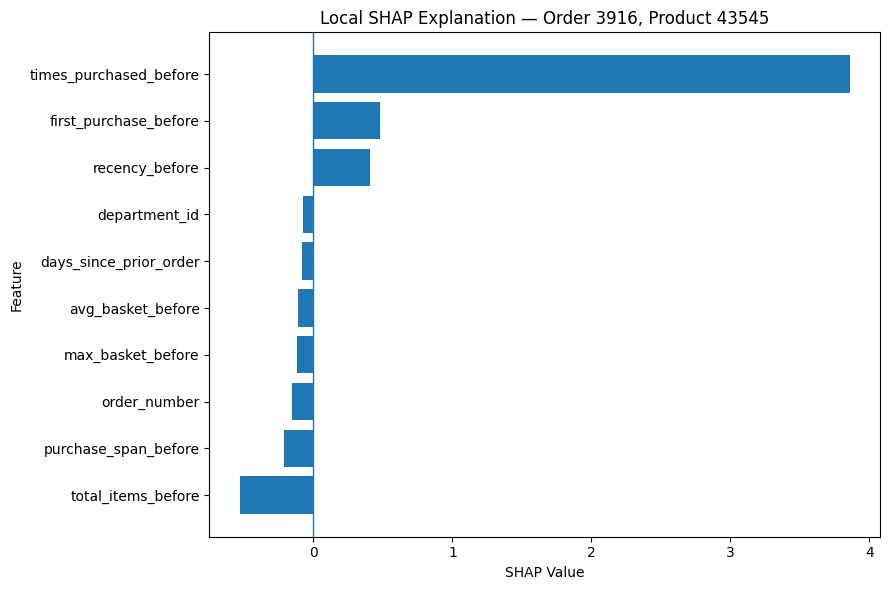

Local SHAP explanation plot saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/local_shap_example_recommendation.png


In [15]:
# ============================================================
# CELL 16 — LOCAL SHAP EXPLANATION PLOT
# ============================================================

plot_example = example_shap.sort_values(
    "shap_value",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_example["feature"],
    plot_example["shap_value"]
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel("SHAP Value")
ax.set_ylabel("Feature")
ax.set_title(
    f"Local SHAP Explanation — Order {example_row['order_id']}, "
    f"Product {example_row['product_id']}"
)

plt.tight_layout()

local_example_plot_path = os.path.join(
    OUTPUT_PATH,
    "local_shap_example_recommendation.png"
)

plt.savefig(
    local_example_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Local SHAP explanation plot saved successfully.")
print("Saved to:", local_example_plot_path)

In [16]:
# ============================================================
# CELL 17 — CREATE RECOMMENDATION-LEVEL EXPLANATIONS
# ============================================================

explanation_columns = [
    "order_id",
    "user_id",
    "product_id",
    "rank",
    "recommendation_score",
    "in_next_basket",
    "top_shap_features",
    "positive_shap_features",
    "negative_shap_features"
]

recommendation_explanations = shap_df[
    explanation_columns
].copy()

print("Recommendation-level explanations created successfully.")
print("Shape:", recommendation_explanations.shape)
print()
print(recommendation_explanations.head(10).to_string(index=False))

Recommendation-level explanations created successfully.
Shape: (20000, 9)

 order_id  user_id  product_id  rank  recommendation_score  in_next_basket                                                 top_shap_features                        positive_shap_features             negative_shap_features
     3916   159909       43545     1              3.464279               1 times_purchased_before, total_items_before, first_purchase_before times_purchased_before, first_purchase_before                 total_items_before
     3916   159909       13176     2              3.423945               1 times_purchased_before, first_purchase_before, total_items_before times_purchased_before, first_purchase_before                 total_items_before
     3916   159909        4793     3              2.776508               1 times_purchased_before, total_items_before, first_purchase_before times_purchased_before, first_purchase_before                 total_items_before
     3916   159909       25931     4 

In [17]:
# ============================================================
# CELL 18 — SAVE RECOMMENDATION-LEVEL EXPLANATIONS
# ============================================================

recommendation_explanations_path = os.path.join(
    OUTPUT_PATH,
    "top20_recommendation_local_shap_explanations.csv"
)

recommendation_explanations.to_csv(
    recommendation_explanations_path,
    index=False
)

print("Recommendation-level SHAP explanations saved successfully.")
print("Saved to:", recommendation_explanations_path)
print("Rows:", len(recommendation_explanations))


Recommendation-level SHAP explanations saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/top20_recommendation_local_shap_explanations.csv
Rows: 20000


In [18]:
# ============================================================
# CELL 19 — AGGREGATE POSITIVE AND NEGATIVE SHAP CONTRIBUTIONS
# ============================================================

positive_counts = {}
negative_counts = {}

for feature in feature_cols:
    shap_column = f"SHAP_{feature}"

    positive_counts[feature] = (
        shap_df[shap_column] > 0
    ).sum()

    negative_counts[feature] = (
        shap_df[shap_column] < 0
    ).sum()

direction_summary = pd.DataFrame({
    "feature": feature_cols,
    "positive_count": [
        positive_counts[feature] for feature in feature_cols
    ],
    "negative_count": [
        negative_counts[feature] for feature in feature_cols
    ]
})

direction_summary["positive_percentage"] = (
    direction_summary["positive_count"] / len(shap_df) * 100
)

direction_summary["negative_percentage"] = (
    direction_summary["negative_count"] / len(shap_df) * 100
)

direction_summary = direction_summary.sort_values(
    "positive_count",
    ascending=False
).reset_index(drop=True)

print("SHAP contribution direction summary calculated successfully.")
print()
print(direction_summary.to_string(index=False))

SHAP contribution direction summary calculated successfully.

                 feature  positive_count  negative_count  positive_percentage  negative_percentage
  times_purchased_before           17587            2413               87.935               12.065
   first_purchase_before           17587            2413               87.935               12.065
    last_purchase_before           17268            2732               86.340               13.660
       avg_basket_before           11877            8123               59.385               40.615
           department_id           10370            9630               51.850               48.150
          recency_before            9212           10788               46.060               53.940
  days_since_prior_order            9070           10930               45.350               54.650
       order_hour_of_day            8367           11633               41.835               58.165
                aisle_id            7538       

In [19]:
# ============================================================
# CELL 20 — SAVE SHAP DIRECTION SUMMARY
# ============================================================

direction_summary_path = os.path.join(
    OUTPUT_PATH,
    "local_shap_direction_summary.csv"
)

direction_summary.to_csv(
    direction_summary_path,
    index=False
)

print("SHAP direction summary saved successfully.")
print("Saved to:", direction_summary_path)
print("Rows:", len(direction_summary))


SHAP direction summary saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/local_shap_direction_summary.csv
Rows: 17


In [20]:
# ============================================================
# CELL 21 — SHAP IMPORTANCE BY RECOMMENDATION RANK
# ============================================================

rank_groups = []

for rank in sorted(shap_df["rank"].unique()):
    rank_data = shap_df[shap_df["rank"] == rank]

    mean_shap = {
        feature: rank_data[f"SHAP_{feature}"].abs().mean()
        for feature in feature_cols
    }

    mean_shap["rank"] = rank
    rank_groups.append(mean_shap)

rank_shap_summary = pd.DataFrame(rank_groups)

rank_shap_summary = rank_shap_summary[
    ["rank"] + feature_cols
]

print("Rank-wise local SHAP importance calculated successfully.")
print("Shape:", rank_shap_summary.shape)
print()
print(rank_shap_summary.head(10).to_string(index=False))

Rank-wise local SHAP importance calculated successfully.
Shape: (20, 18)

 rank  order_number  order_dow  order_hour_of_day  days_since_prior_order  times_purchased_before  first_purchase_before  last_purchase_before  recency_before  purchase_span_before  was_previously_purchased  aisle_id  department_id  previous_orders  avg_basket_before  max_basket_before  total_items_before  order_progress
    1      0.201114   0.006347           0.012109                0.039614                3.303320               0.527909              0.052413        0.343142              0.165843                       0.0  0.095812       0.050316         0.031454           0.106546           0.108706            0.535646        0.007520
    2      0.205077   0.005481           0.011262                0.038176                2.958936               0.516658              0.048523        0.340519              0.171941                       0.0  0.083952       0.051105         0.032888           0.113481           0.

In [21]:
# ============================================================
# CELL 22 — SAVE RANK-WISE SHAP SUMMARY
# ============================================================

rank_shap_summary_path = os.path.join(
    OUTPUT_PATH,
    "local_shap_importance_by_rank.csv"
)

rank_shap_summary.to_csv(
    rank_shap_summary_path,
    index=False
)

print("Rank-wise SHAP summary saved successfully.")
print("Saved to:", rank_shap_summary_path)
print("Rows:", len(rank_shap_summary))



Rank-wise SHAP summary saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/local_shap_importance_by_rank.csv
Rows: 20


In [22]:
# ============================================================
# CELL 23 — CREATE TOP-5 RECOMMENDATION EXPLANATIONS
# ============================================================

top5_explanations = recommendation_explanations[
    recommendation_explanations["rank"] <= 5
].copy()

top5_explanations = top5_explanations[
    [
        "order_id",
        "user_id",
        "product_id",
        "rank",
        "recommendation_score",
        "in_next_basket",
        "top_shap_features",
        "positive_shap_features",
        "negative_shap_features"
    ]
]

print("Top-5 recommendation explanations created successfully.")
print("Shape:", top5_explanations.shape)
print("Unique orders:", top5_explanations["order_id"].nunique())
print()
print(top5_explanations.head(10).to_string(index=False))

Top-5 recommendation explanations created successfully.
Shape: (5000, 9)
Unique orders: 1000

 order_id  user_id  product_id  rank  recommendation_score  in_next_basket                                                 top_shap_features                        positive_shap_features negative_shap_features
     3916   159909       43545     1              3.464279               1 times_purchased_before, total_items_before, first_purchase_before times_purchased_before, first_purchase_before     total_items_before
     3916   159909       13176     2              3.423945               1 times_purchased_before, first_purchase_before, total_items_before times_purchased_before, first_purchase_before     total_items_before
     3916   159909        4793     3              2.776508               1 times_purchased_before, total_items_before, first_purchase_before times_purchased_before, first_purchase_before     total_items_before
     3916   159909       25931     4              2.589228        

In [23]:
# ============================================================
# CELL 24 — SAVE TOP-5 RECOMMENDATION EXPLANATIONS
# ============================================================

top5_explanations_path = os.path.join(
    OUTPUT_PATH,
    "top5_recommendation_local_shap_explanations.csv"
)

top5_explanations.to_csv(
    top5_explanations_path,
    index=False
)

print("Top-5 recommendation explanations saved successfully.")
print("Saved to:", top5_explanations_path)
print("Rows:", len(top5_explanations))
print("Unique orders:", top5_explanations["order_id"].nunique())

Top-5 recommendation explanations saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/top5_recommendation_local_shap_explanations.csv
Rows: 5000
Unique orders: 1000


In [24]:
# ============================================================
# CELL 25 — CREATE FINAL LOCAL SHAP SUMMARY
# ============================================================

top_features = local_shap_summary.head(5)["feature"].tolist()

final_local_shap_summary = pd.DataFrame({
    "analysis": [
        "Total recommendations explained",
        "Target orders analyzed",
        "Features explained",
        "Top local SHAP feature",
        "Second most influential feature",
        "Third most influential feature",
        "Fourth most influential feature",
        "Fifth most influential feature"
    ],
    "value": [
        len(shap_df),
        shap_df["order_id"].nunique(),
        len(feature_cols),
        top_features[0],
        top_features[1],
        top_features[2],
        top_features[3],
        top_features[4]
    ]
})

print("Final local SHAP summary created successfully.")
print()
print(final_local_shap_summary.to_string(index=False))

Final local SHAP summary created successfully.

                       analysis                  value
Total recommendations explained                  20000
         Target orders analyzed                   1000
             Features explained                     17
         Top local SHAP feature times_purchased_before
Second most influential feature     total_items_before
 Third most influential feature         recency_before
Fourth most influential feature  first_purchase_before
 Fifth most influential feature           order_number


In [25]:
# ============================================================
# CELL 26 — SAVE FINAL LOCAL SHAP SUMMARY
# ============================================================

final_local_shap_summary_path = os.path.join(
    OUTPUT_PATH,
    "final_local_shap_summary.csv"
)

final_local_shap_summary.to_csv(
    final_local_shap_summary_path,
    index=False
)

print("Final local SHAP summary saved successfully.")
print("Saved to:", final_local_shap_summary_path)
print("Rows:", len(final_local_shap_summary))

Final local SHAP summary saved successfully.
Saved to: /content/drive/MyDrive/ML_Market_Basket_Analysis/Models/Model_Outputs/final_local_shap_summary.csv
Rows: 8


In [26]:
# ============================================================
# CELL 27 — FINAL NOTEBOOK 13 VERIFICATION
# ============================================================

required_files = [
    "local_shap_feature_importance.csv",
    "local_shap_direction_summary.csv",
    "local_shap_importance_by_rank.csv",
    "top20_recommendation_local_shap_explanations.csv",
    "top5_recommendation_local_shap_explanations.csv",
    "final_local_shap_summary.csv",
    "local_shap_feature_importance.png",
    "local_shap_example_recommendation.png"
]

print("Notebook 13 — Final Verification")
print("=" * 50)

all_found = True

for filename in required_files:
    filepath = os.path.join(OUTPUT_PATH, filename)
    status = "FOUND" if os.path.exists(filepath) else "MISSING"

    print(f"{filename}: {status}")

    if status == "MISSING":
        all_found = False

print()
print("Recommendation rows:", len(recommendations))
print("Unique target orders:", recommendations["order_id"].nunique())
print("SHAP matrix shape:", shap_values.shape)
print("Feature count:", len(feature_cols))
print("Missing SHAP values:", np.isnan(shap_values).sum())

print()

if all_found:
    print("Notebook 13 verification completed successfully.")
else:
    print("Notebook 13 verification found missing artifacts.")

Notebook 13 — Final Verification
local_shap_feature_importance.csv: FOUND
local_shap_direction_summary.csv: FOUND
local_shap_importance_by_rank.csv: FOUND
top20_recommendation_local_shap_explanations.csv: FOUND
top5_recommendation_local_shap_explanations.csv: FOUND
final_local_shap_summary.csv: FOUND
local_shap_feature_importance.png: FOUND
local_shap_example_recommendation.png: FOUND

Recommendation rows: 20000
Unique target orders: 1000
SHAP matrix shape: (20000, 17)
Feature count: 17
Missing SHAP values: 0

Notebook 13 verification completed successfully.
